[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HunterBushnell/SCP/blob/main/0_pipeline.ipynb)

# SCP Pipeline - Compact Steps 1-5

The recommended simple workflow for an already prepared tune. Run All does not start a model or simulation; it only renders the five panels. Click the enabled actions in order.

Use `1_setup.ipynb` to import or configure a model, and the numbered notebooks for detailed controls. ACT active tuning is experimental and review-only.

> After changing `cell_config.json`, morphology, fit/HOC, or MOD sources, restart the kernel and rerun from the top. Runtime, target, geometry, and synapse configs reload when used.

## Notebook Setup: Environment

Run this once. The cell finds SCP locally or clones it in a fresh Colab runtime. Its source is collapsed to keep the workflow focused.

In [1]:
try:
    ip = get_ipython()
except NameError:
    ip = None
if ip is not None:
    try:
        ip.run_line_magic("load_ext", "autoreload")
        ip.run_line_magic("autoreload", "2")
    except Exception as exc:
        print(f"IPython autoreload unavailable ({exc}); continuing.")

import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
SCP_REPO_URL = os.environ.get("SCP_REPO_URL", "https://github.com/HunterBushnell/SCP.git")
SCP_REPO_BRANCH = os.environ.get("SCP_REPO_BRANCH", "") or None
SCP_REPO_DIR = Path(os.environ.get("SCP_REPO_DIR", "/content/SCP" if IN_COLAB else str(Path.cwd() / "SCP")))
INSTALL_DEPS = None  # None installs automatically in Colab and not locally.

def _looks_like_scp(path):
    return (path / "modules").is_dir() and (path / "run_pipeline.py").is_file()

repo_root = None
env_root = os.environ.get("SCP_ROOT")
if env_root and _looks_like_scp(Path(env_root).expanduser()):
    repo_root = Path(env_root).expanduser().resolve()
else:
    start = Path.cwd().resolve()
    candidates = [start, *start.parents]
    for base in (start, start.parent):
        try:
            candidates.extend(child for child in base.iterdir() if child.is_dir())
        except Exception:
            pass
    for candidate in candidates:
        if _looks_like_scp(candidate):
            repo_root = candidate.resolve()
            break

if repo_root is None:
    if not IN_COLAB and os.environ.get("SCP_AUTO_CLONE", "0") not in {"1", "true", "True"}:
        raise FileNotFoundError("Could not find SCP. Set SCP_ROOT or run from the repo.")
    clone_url = SCP_REPO_URL
    token = os.environ.get("SCP_GIT_TOKEN") or os.environ.get("SCP_GITHUB_TOKEN") or os.environ.get("GITHUB_TOKEN")
    if token and clone_url.startswith("https://") and "@" not in clone_url:
        clone_url = clone_url.replace("https://", f"https://{token}@", 1)
    clone_command = ["git", "clone", "--depth", "1"]
    if SCP_REPO_BRANCH:
        clone_command += ["--branch", SCP_REPO_BRANCH]
    clone_command += [clone_url, str(SCP_REPO_DIR)]
    subprocess.check_call(clone_command)
    repo_root = SCP_REPO_DIR.resolve()

os.environ["SCP_ROOT"] = str(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from modules.notebooks.bootstrap import finish_step5_notebook_setup, ensure_python_package
setup = finish_step5_notebook_setup(repo_root, install_deps=INSTALL_DEPS, check_external_inputs=False)
repo_root = setup["repo_root"]
IN_COLAB = setup["in_colab"]
if INSTALL_DEPS is True or (INSTALL_DEPS is None and IN_COLAB):
    ensure_python_package("ipywidgets")

from modules.notebooks import PipelineNotebookUI

Runtime: local
SCP repo: /home/hrbncv/SCP


## Notebook Setup: Settings

These Python values initialize the panels and remain available for code-first edits. Widget changes update this mapping; rerun this cell to push edited values back into unlocked controls. Model-selection values lock after Step 1 and require a kernel restart to change.

In [2]:
pipeline_settings = {
    # Step 1: choose an already prepared tune.
    "cell_name": "PV",
    "tune_name": "tuned",
    "tune_dir_override": None,
    "quiet_step1_output": True,  # Show only SCP's concise load summary.
    "recompile_modfiles": False,

    # Step 2: protocol controls; ACT proposals are a separate review-only action.
    "passive_amps_pA": [-50, -100],
    "passive_target_overrides": {},  # Empty = values displayed from target_config.json.
    "passive_protocol_overrides": {},

    # Step 3: active/FI checks plus optional review-only ACT tuning.
    "active_amps_pA": [150, 300],
    "active_protocol_overrides": {},
    "active_spike_threshold_mV": -20,
    "active_include_currents": True,
    "active_current_display_amp_pA": None,  # None = last active amplitude.
    "fi_amps_pA": list(range(0, 301, 50)),
    "fi_protocol_overrides": {},
    "fi_spike_threshold_mV": -20,
    "act_active_module": None,  # None selects the first incomplete module.
    "act_n_cpus": None,  # None uses the ACT config or 4, capped locally.
    "act_workspace_override": None,
    "act_overrides": {},  # Advanced widget edits synchronize here.
    "act_overwrite_outputs": False,

    # Step 4: opt in before initializing BMTool.
    "enable_synapse_tuning": False,
    "synapse_connection": None,

    # Step 5: input preview, saved simulation, and plotting are separate actions.
    "n_trials": 1,
    "seed": None,
    "run_iclamp": False,
    "output_stem": None,
    "quiet_input_preview_output": True,
    "quiet_simulation_output": True,
    # Session-only recursive overrides for advanced Run Simulation fields.
    "simulation_overrides": {},
    "input_preview_groups": None,  # None = all enabled configured groups.
    "input_preview_plots": [
        "weight_distribution",
        "distance_distribution",
        "weight_vs_distance",
    ],
    "input_preview_trial_idx": 0,
    "input_preview_show_table": True,
    "input_preview_histogram_density": True,
    "input_preview_distance_bin_um": 25.0,
    "input_preview_weight_bin": None,  # None = automatic.
    "input_preview_plot_columns": 3,
    "input_preview_plot_size": "compact",
    # Step 5: immediate compact plots; use Step 6 for detailed analysis.
    "diagnostic_plots": [
        "input_rate",
        "membrane_voltage",
        "output_rate",
        "output_raster",
    ],
    "diagnostic_trial_idx": 0,
    "diagnostic_window_mode": "stimulus",
    "diagnostic_window_start_ms": None,
    "diagnostic_window_stop_ms": None,
    "diagnostic_window_padding_ms": 100.0,
    "diagnostic_rate_bin_ms": None,  # None = resolved run-config value.
    "diagnostic_smoothing_ms": None,  # None = resolved run-config value.
    "diagnostic_raster_style": "dot",
    "diagnostic_input_groups": None,  # None = all saved groups.
    "diagnostic_show_stimulus": True,
    "diagnostic_figure_size": "compact",
}

if "pipeline_ui" in globals():
    pipeline_ui.apply_settings(pipeline_settings)

## Step 1: Setup and Load the Tune

Select an already prepared cell/tune and click **Prepare and load**. **Quiet load** keeps routine output in `pipeline_ui.step1_load_log`. A successful load locks model selection for the one-cell-per-kernel lifecycle.

In [3]:
if "pipeline_ui" not in globals():
    pipeline_ui = PipelineNotebookUI(repo_root, pipeline_settings)
else:
    pipeline_ui.apply_settings(pipeline_settings)
pipeline_ui.step1_panel()

## Step 2: Passive Tuning

Use **Compute ACT proposal** for review-only suggested passive values, then **Run passive** to inspect traces and target comparisons. Target fields start from `target_config.json`; widget edits are session-only. Timing controls are under **Show advanced options**.

In [4]:
pipeline_ui.step2_panel()

## Step 3: Active Tuning and FI Curve

Run the **Active protocol** and **FI curve** cards independently. Timing, thresholds, and ionic-current display controls are under **Show advanced options**.

**ACT active tuning is experimental, review-only, and not release-blocking.** Its isolated worker never applies predictions to model files. The guided sequence includes **Run selected module**, **Cancel**, and **Review evaluation**; use `3_active.ipynb` for the detailed workflow.

In [ ]:
pipeline_ui.step3_panel()

## Step 4: Synapse Tuning (Optional)

Enable and run **Initialize BMTool**, then use **Single Event** and **Interactive Tuner** independently. Copy accepted values into the appropriate synapse JSON before Step 5.

In [ ]:
pipeline_ui.step4_panel()

## Step 5: Check Inputs, Simulate, and Plot

Use **Check Inputs**, **Run Simulation**, then **Plot Results**. The shared seed is displayed in Check Inputs and also used by simulation. Quiet subprocess logs remain available as `pipeline_ui.input_preview_log` and `pipeline_ui.simulation_log`. Advanced widget edits are session-only and do not modify `sim_config.json`; use Step 6 for detailed analysis and export.

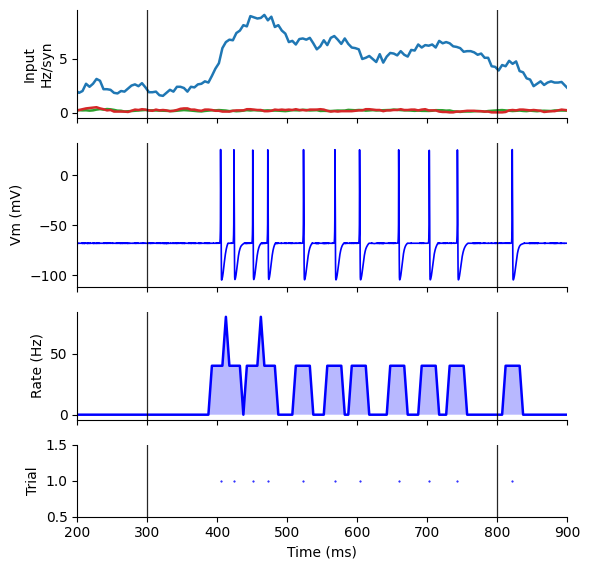

In [7]:
pipeline_ui.step5_panel()

## Next: Step 6 Analysis

Open `6_analysis.ipynb` for full saved-run analysis. Return to the corresponding numbered notebook whenever you need the advanced controls intentionally omitted here.